<a href="https://colab.research.google.com/github/Amri1003/Machine_Learning_Projects/blob/main/movieRecommendationProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Movie Recommendation System — End-to-End Project

## Project Overview
In this project, we build a **Movie Recommendation System** from scratch using a sample dataset.

We cover **all major concepts** from the Recommendation Systems module:

| Concept | Section |
|---|---|
| User-Based Collaborative Filtering | Section 2 |
| Item-Based Collaborative Filtering | Section 3 |
| Matrix Factorization (MF) | Section 4 |
| Singular Value Decomposition (SVD) | Section 5 |
| Content-Based Filtering | Section 6 |
| Hybrid Filtering | Section 7 |
| GetTopN Function | Section 8 |
| Hit Rate Evaluation | Section 8 |
| Cold Start Problem | Section 9 |
| Implicit vs Explicit Feedback | Section 10 |

---
**Dataset:** A sample movie ratings dataset (created in Section 1)

## Section 1: Create Sample Dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.sparse.linalg import svds
import scipy.sparse as sp
import operator
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [5]:
# ── Sample Movies Dataset ──────────────────────────────────────────────────
movies_data = {
    'movie_id': list(range(1, 21)),
    'title': [
        'The Dark Knight', 'Inception', 'Interstellar', 'The Matrix',
        'Avengers: Endgame', 'Iron Man', 'Doctor Strange', 'Thor',
        'The Notebook', 'Titanic', 'La La Land', 'Pride & Prejudice',
        'The Conjuring', 'Get Out', 'A Quiet Place', 'Hereditary',
        'The Grand Budapest Hotel', 'Parasite', 'Joker', 'Whiplash'
    ],
    'genre': [
        'Action', 'Sci-Fi', 'Sci-Fi', 'Action',
        'Action', 'Action', 'Action', 'Action',
        'Romance', 'Romance', 'Romance', 'Romance',
        'Horror', 'Horror', 'Horror', 'Horror',
        'Drama', 'Drama', 'Drama', 'Drama'
    ],
    'director': [
        'Christopher Nolan', 'Christopher Nolan', 'Christopher Nolan', 'Wachowski',
        'Russo Brothers', 'Jon Favreau', 'Scott Derrickson', 'Kenneth Branagh',
        'Nick Cassavetes', 'James Cameron', 'Damien Chazelle', 'Joe Wright',
        'James Wan', 'Jordan Peele', 'John Krasinski', 'Ari Aster',
        'Wes Anderson', 'Bong Joon-ho', 'Todd Phillips', 'Damien Chazelle'
    ],
    'release_year': [
        2008, 2010, 2014, 1999,
        2019, 2008, 2016, 2011,
        2004, 1997, 2016, 2005,
        2013, 2017, 2018, 2018,
        2014, 2019, 2019, 2014
    ],
    'avg_rating': [9.0, 8.8, 8.6, 8.7, 8.4, 7.9, 7.5, 7.0,
                   7.9, 7.8, 8.0, 7.8, 7.5, 7.7, 7.5, 7.3,
                   8.1, 8.6, 8.5, 8.5]
}

movies_df = pd.DataFrame(movies_data)
print(f"Movies dataset: {movies_df.shape[0]} movies")
movies_df.head(10)

Movies dataset: 20 movies


,movie_id,title,genre,director,release_year,avg_rating
0,1,The Dark Knight,Action,Christopher Nolan,2008,9.0
1,2,Inception,Sci-Fi,Christopher Nolan,2010,8.8
2,3,Interstellar,Sci-Fi,Christopher Nolan,2014,8.6
3,4,The Matrix,Action,Wachowski,1999,8.7
4,5,Avengers: Endgame,Action,Russo Brothers,2019,8.4
5,6,Iron Man,Action,Jon Favreau,2008,7.9
6,7,Doctor Strange,Action,Scott Derrickson,2016,7.5
7,8,Thor,Action,Kenneth Branagh,2011,7.0
8,9,The Notebook,Romance,Nick Cassavetes,2004,7.9
9,10,Titanic,Romance,James Cameron,1997,7.8


In [6]:
# ── Sample Ratings Dataset ─────────────────────────────────────────────────
np.random.seed(42)

n_users = 20
n_movies = 20

# Simulate user rating patterns (genre preference clusters)
user_preferences = {
    'action_lovers': [1, 4, 5, 6, 7, 8],      # users 1-6
    'romance_lovers': [9, 10, 11, 12],          # users 7-10
    'horror_lovers': [13, 14, 15, 16],          # users 11-14
    'drama_lovers': [17, 18, 19, 20]            # users 15-20
}

ratings_list = []
user_id_counter = 1

for group, movie_ids in user_preferences.items():
    n_group_users = 5  # 5 users per preference group
    for _ in range(n_group_users):
        # High ratings for preferred genre movies
        for movie_id in movie_ids:
            rating = np.random.choice([4, 5], p=[0.3, 0.7])  # high rating
            ratings_list.append({'user_id': user_id_counter, 'movie_id': movie_id, 'rating': int(rating)})

        # Low/medium ratings for a few other movies (not all)
        other_movies = [m for m in range(1, 21) if m not in movie_ids]
        sampled_others = np.random.choice(other_movies, size=4, replace=False)
        for movie_id in sampled_others:
            rating = np.random.choice([1, 2, 3], p=[0.2, 0.3, 0.5])
            ratings_list.append({'user_id': user_id_counter, 'movie_id': int(movie_id), 'rating': int(rating)})

        user_id_counter += 1

ratings_df = pd.DataFrame(ratings_list)
print(f"Ratings dataset: {len(ratings_df)} ratings | {ratings_df['user_id'].nunique()} users | {ratings_df['movie_id'].nunique()} movies")
ratings_df.head(10)

Ratings dataset: 170 ratings | 20 users | 20 movies


,user_id,movie_id,rating
0,1,1,5
1,1,4,5
2,1,5,5
3,1,6,5
4,1,7,4
5,1,8,4
6,1,2,1
7,1,13,3
8,1,16,3
9,1,3,3


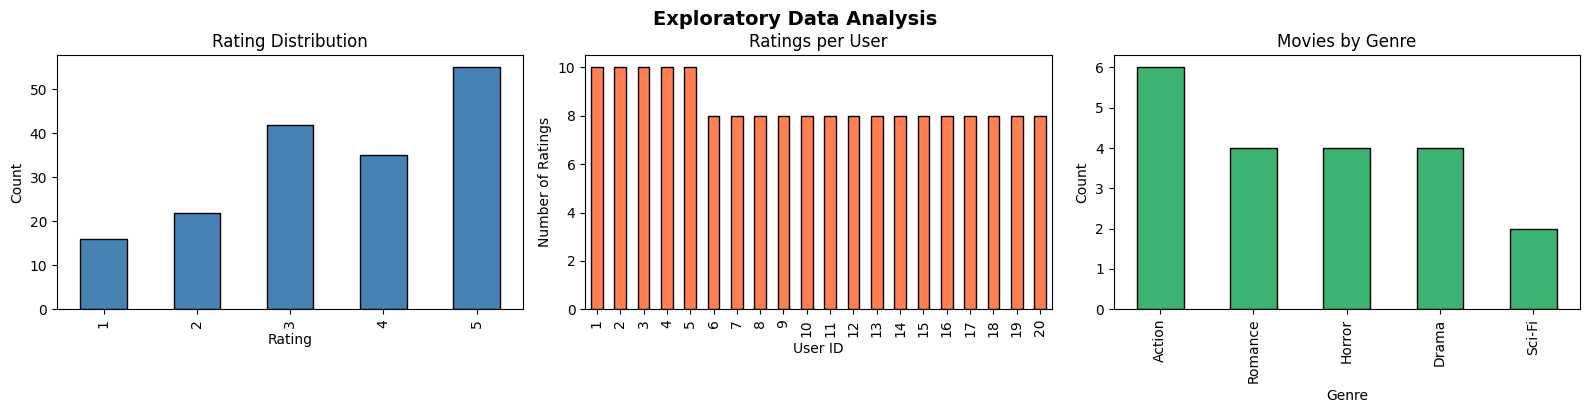


Basic Statistics:
count    170.00
mean       3.54
std        1.32
min        1.00
25%        3.00
50%        4.00
75%        5.00
max        5.00
Name: rating, dtype: float64


In [7]:
# ── EDA ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Rating distribution
ratings_df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Ratings per user
ratings_df.groupby('user_id')['rating'].count().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Ratings per User')
axes[1].set_xlabel('User ID')
axes[1].set_ylabel('Number of Ratings')

# Genre distribution in movies
movies_df['genre'].value_counts().plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='black')
axes[2].set_title('Movies by Genre')
axes[2].set_xlabel('Genre')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.show()

print("\nBasic Statistics:")
print(ratings_df['rating'].describe().round(2))

## Section 2: Build User-Item Rating Matrix

Rating Matrix Shape: (20, 20)  (users × movies)
Sparsity: 57.5%


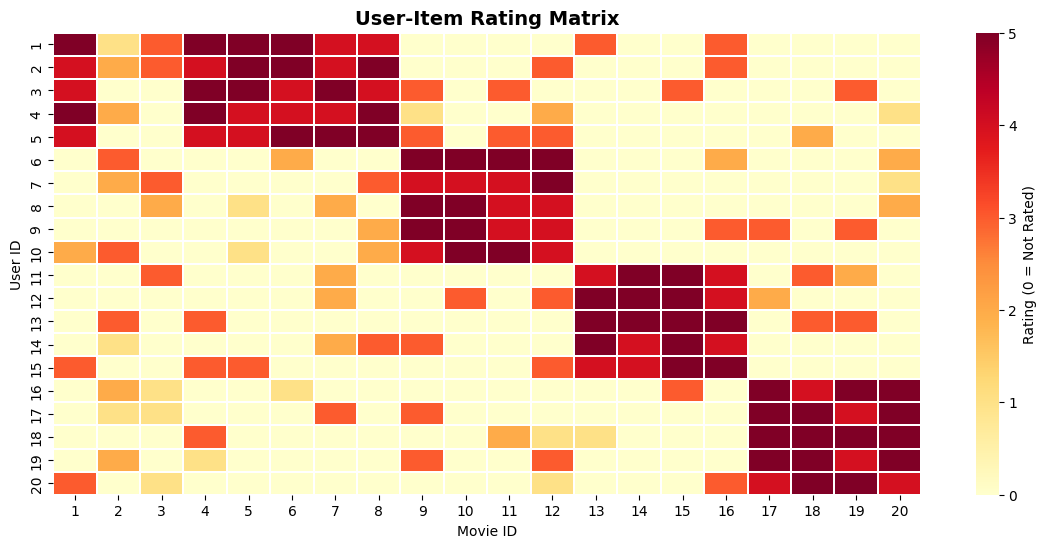

In [8]:
# Create the User-Item Rating Matrix
rating_matrix = ratings_df.pivot_table(index='user_id', columns='movie_id', values='rating').fillna(0)

print(f"Rating Matrix Shape: {rating_matrix.shape}  (users × movies)")
print(f"Sparsity: {(rating_matrix == 0).sum().sum() / rating_matrix.size * 100:.1f}%")

# Visualize the matrix
plt.figure(figsize=(14, 6))
sns.heatmap(rating_matrix, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Rating (0 = Not Rated)'}, annot=False)
plt.title('User-Item Rating Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Movie ID')
plt.ylabel('User ID')
plt.show()

## Section 3: User-Based Collaborative Filtering

**Idea:** Find users similar to the target user, then recommend movies those similar users liked.

**Similarity formula (Cosine Similarity):**
$$\text{similarity}(u, v) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\|\|\mathbf{B}\|}$$

In [9]:
def similar_users(user_id, matrix, k=3):
    """Find top-k most similar users to the given user using cosine similarity."""
    user_vector = matrix[matrix.index == user_id]
    other_users = matrix[matrix.index != user_id]

    similarities = cosine_similarity(user_vector, other_users)[0].tolist()
    indices = other_users.index.tolist()

    index_similarity = dict(zip(indices, similarities))
    sorted_similar = sorted(index_similarity.items(), key=operator.itemgetter(1), reverse=True)

    top_k = sorted_similar[:k]
    return [u[0] for u in top_k], [round(u[1], 4) for u in top_k]


def user_based_recommend(target_user, matrix, n_items=5, k=3):
    """Recommend movies for a user based on similar users' preferences."""
    similar_user_ids, scores = similar_users(target_user, matrix, k)

    # Average ratings of similar users
    sim_users_ratings = matrix[matrix.index.isin(similar_user_ids)].mean(axis=0)

    # Filter out movies already rated by target user
    target_rated = matrix.loc[target_user]
    unseen_mask = target_rated == 0

    # Sort and pick top-n unseen movies
    recs = sim_users_ratings[unseen_mask].sort_values(ascending=False).head(n_items)
    rec_movie_ids = recs.index.tolist()

    result = movies_df[movies_df['movie_id'].isin(rec_movie_ids)][['movie_id', 'title', 'genre']].copy()
    result['predicted_score'] = result['movie_id'].map(recs.to_dict()).round(2)
    return result.sort_values('predicted_score', ascending=False), similar_user_ids, scores


# Test for User 1
TARGET_USER = 1
recs, sim_ids, sim_scores = user_based_recommend(TARGET_USER, rating_matrix, n_items=5)

print(f"🔍 Similar users to User {TARGET_USER}: {list(zip(sim_ids, sim_scores))}")
print(f"\n🎬 Top 5 User-Based Recommendations for User {TARGET_USER}:")
print(recs.to_string(index=False))

🔍 Similar users to User 1: [(2, 0.9301), (4, 0.8775), (5, 0.7963)]

🎬 Top 5 User-Based Recommendations for User 1:
 movie_id             title   genre  predicted_score
       12 Pride & Prejudice Romance             2.67
        9      The Notebook Romance             1.33
       11        La La Land Romance             1.00
       18          Parasite   Drama             0.67
       20          Whiplash   Drama             0.33


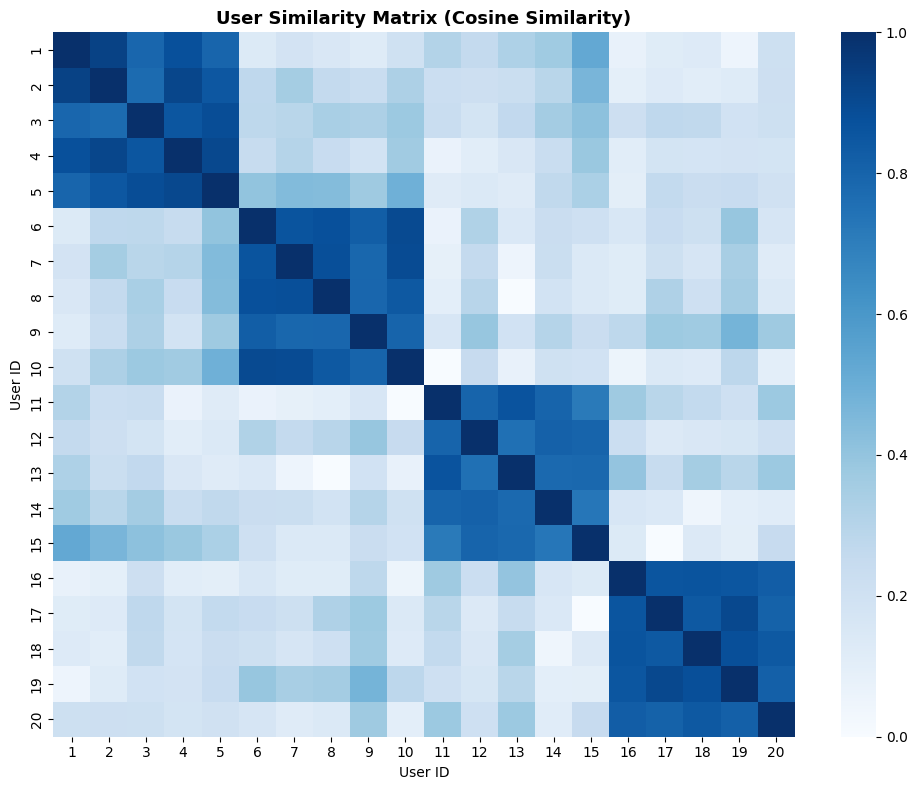

In [10]:
# Visualize cosine similarity between all users
user_sim_matrix = cosine_similarity(rating_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(user_sim_matrix, cmap='Blues', annot=False,
            xticklabels=rating_matrix.index, yticklabels=rating_matrix.index)
plt.title('User Similarity Matrix (Cosine Similarity)', fontsize=13, fontweight='bold')
plt.xlabel('User ID')
plt.ylabel('User ID')
plt.tight_layout()
plt.show()

## Section 4: Item-Based Collaborative Filtering

**Idea:** Find movies similar to what the user already likes, then recommend those.

$$\text{similarity}(i, j) = \frac{\sum_{u} r_{u,i} \cdot r_{u,j}}{\sqrt{\sum_{u} r_{u,i}^2} \cdot \sqrt{\sum_{u} r_{u,j}^2}}$$

In [11]:
# Item-Item similarity matrix (transpose so items are rows)
item_sim_matrix = cosine_similarity(rating_matrix.T)
item_sim_df = pd.DataFrame(item_sim_matrix,
                            index=rating_matrix.columns,
                            columns=rating_matrix.columns)

def get_similar_movies(movie_id, n=5):
    """Get top-n movies similar to the given movie."""
    sim_scores = item_sim_df[movie_id].drop(movie_id).sort_values(ascending=False).head(n)
    result = movies_df[movies_df['movie_id'].isin(sim_scores.index)][['movie_id', 'title', 'genre']].copy()
    result['similarity'] = result['movie_id'].map(sim_scores.to_dict()).round(4)
    return result.sort_values('similarity', ascending=False)


def item_based_recommend(target_user, matrix, n_items=5):
    """Recommend movies for a user based on item-item similarity."""
    user_ratings = matrix.loc[target_user]
    rated_movies = user_ratings[user_ratings > 0].index.tolist()
    unrated_movies = user_ratings[user_ratings == 0].index.tolist()

    predicted_scores = {}
    for unrated in unrated_movies:
        sim_sum = 0
        weighted_sum = 0
        for rated in rated_movies:
            sim = item_sim_df.loc[unrated, rated]
            weighted_sum += sim * user_ratings[rated]
            sim_sum += abs(sim)
        if sim_sum > 0:
            predicted_scores[unrated] = weighted_sum / sim_sum

    top_movies = sorted(predicted_scores.items(), key=lambda x: x[1], reverse=True)[:n_items]
    top_ids = [m[0] for m in top_movies]
    top_scores = {m[0]: round(m[1], 2) for m in top_movies}

    result = movies_df[movies_df['movie_id'].isin(top_ids)][['movie_id', 'title', 'genre']].copy()
    result['predicted_score'] = result['movie_id'].map(top_scores)
    return result.sort_values('predicted_score', ascending=False)


# Test
SAMPLE_MOVIE = 1  # The Dark Knight
movie_title = movies_df[movies_df['movie_id'] == SAMPLE_MOVIE]['title'].values[0]
print(f"🎬 Movies similar to '{movie_title}':")
print(get_similar_movies(SAMPLE_MOVIE).to_string(index=False))

print(f"\n🎬 Top 5 Item-Based Recommendations for User {TARGET_USER}:")
print(item_based_recommend(TARGET_USER, rating_matrix).to_string(index=False))

🎬 Movies similar to 'The Dark Knight':
 movie_id             title  genre  similarity
        5 Avengers: Endgame Action      0.9412
        4        The Matrix Action      0.8721
        6          Iron Man Action      0.8712
        8              Thor Action      0.8311
        7    Doctor Strange Action      0.7902

🎬 Top 5 Item-Based Recommendations for User 1:
 movie_id             title   genre  predicted_score
       11        La La Land Romance             3.73
       12 Pride & Prejudice Romance             3.66
        9      The Notebook Romance             3.63
       19             Joker   Drama             3.50
       15     A Quiet Place  Horror             3.46


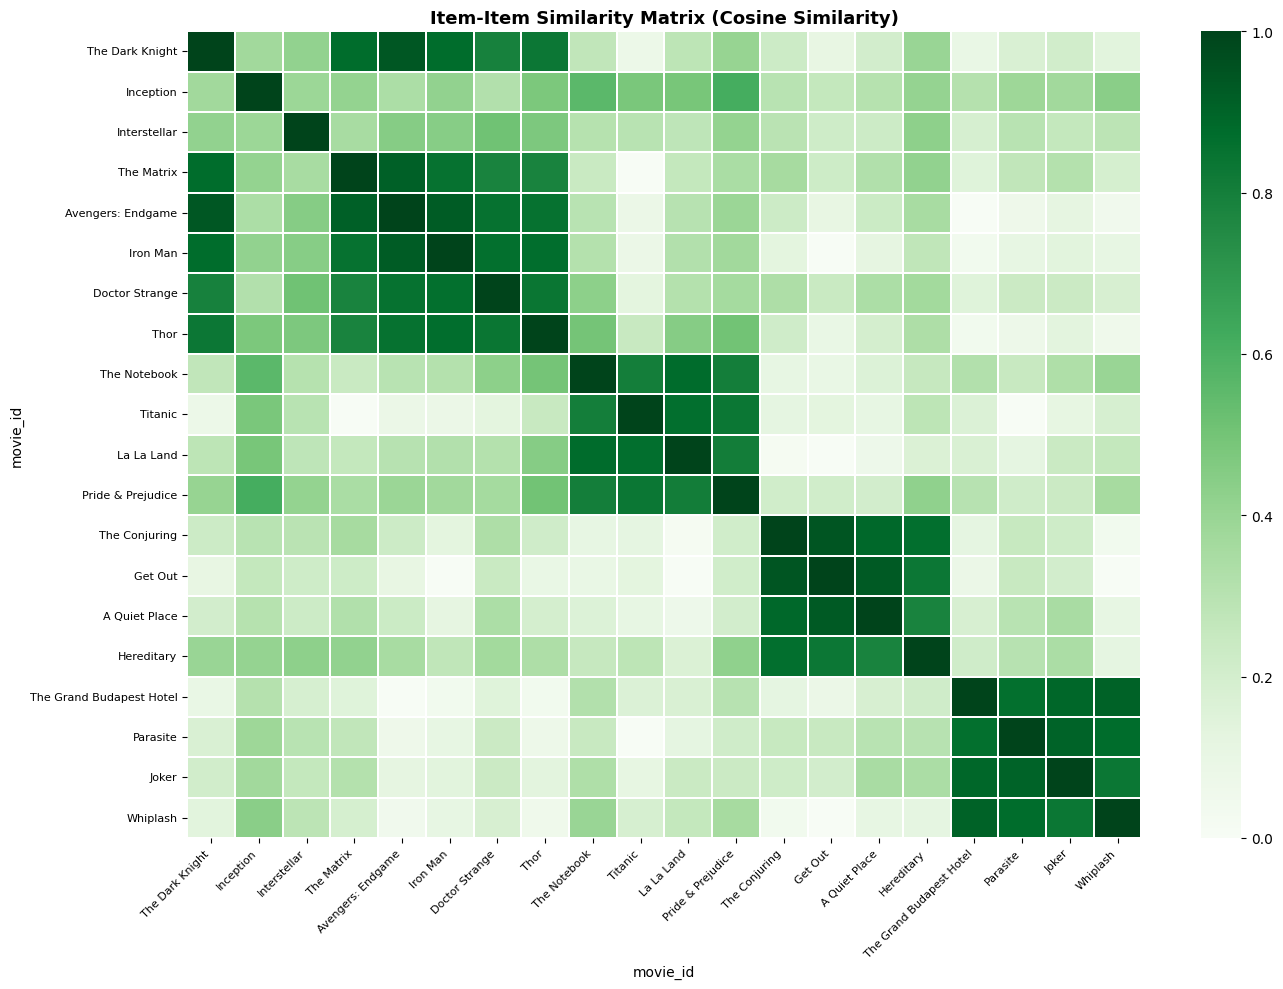

In [12]:
# Visualize Item Similarity Heatmap
movie_labels = movies_df.set_index('movie_id')['title'].to_dict()

plt.figure(figsize=(14, 10))
tick_labels = [movie_labels.get(mid, str(mid)) for mid in item_sim_df.index]
sns.heatmap(item_sim_df, cmap='Greens',
            xticklabels=tick_labels, yticklabels=tick_labels,
            linewidths=0.1)
plt.title('Item-Item Similarity Matrix (Cosine Similarity)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## Section 5: Matrix Factorization (MF)

**Idea:** Decompose the rating matrix R into two smaller matrices P (users × latent factors) and Q (items × latent factors) using gradient descent.

$$R \approx P \times Q^T$$

The update rules for gradient descent:
$$P_{ik} \leftarrow P_{ik} + \alpha \cdot (2 \cdot e_{ij} \cdot Q_{kj} - \beta \cdot P_{ik})$$
$$Q_{kj} \leftarrow Q_{kj} + \alpha \cdot (2 \cdot e_{ij} \cdot P_{ik} - \beta \cdot Q_{kj})$$

⚙️  Running Matrix Factorization (this may take a moment)...
✅ Done! Final error: 20.8326


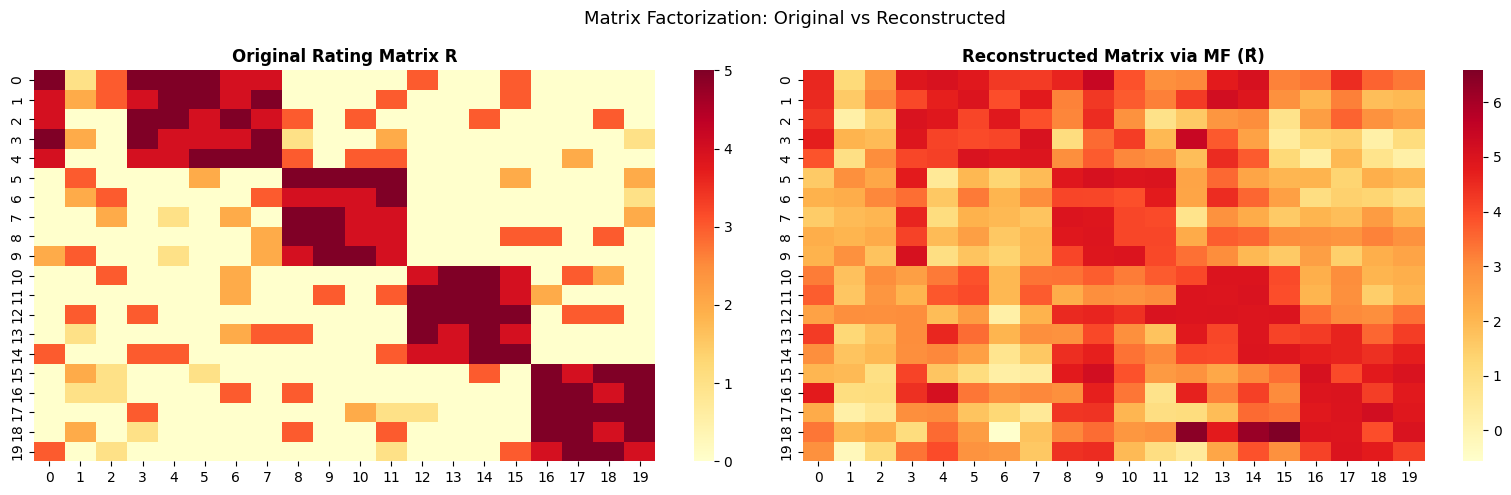

In [13]:
def matrix_factorization(R, K=5, steps=3000, alpha=0.002, beta=0.02):
    """
    Matrix Factorization using Gradient Descent.
    R: rating matrix (numpy array)
    K: number of latent factors
    alpha: learning rate
    beta: regularization strength
    """
    N, M = R.shape
    P = np.random.rand(N, K)  # User latent factor matrix
    Q = np.random.rand(M, K)  # Item latent factor matrix
    Q = Q.T  # Transpose for easy multiplication

    error_history = []

    for step in range(steps):
        for i in range(N):
            for j in range(M):
                if R[i, j] > 0:
                    eij = R[i, j] - np.dot(P[i, :], Q[:, j])
                    for k in range(K):
                        P[i][k] += alpha * (2 * eij * Q[k][j] - beta * P[i][k])
                        Q[k][j] += alpha * (2 * eij * P[i][k] - beta * Q[k][j])

        # Compute total error every 200 steps
        if step % 200 == 0:
            e = 0
            for i in range(N):
                for j in range(M):
                    if R[i, j] > 0:
                        e += (R[i, j] - np.dot(P[i, :], Q[:, j])) ** 2
                        for k in range(K):
                            e += (beta / 2) * (P[i][k] ** 2 + Q[k][j] ** 2)
            error_history.append((step, e))
            if e < 0.1:
                break

    return P, Q.T, error_history


# Run MF on rating matrix
R_array = rating_matrix.values.astype(float)
print("⚙️  Running Matrix Factorization (this may take a moment)...")
P, Q, err_hist = matrix_factorization(R_array, K=5, steps=2000)

# Reconstruct the matrix
R_pred_mf = np.dot(P, Q.T)
print(f"✅ Done! Final error: {err_hist[-1][1]:.4f}")

# Compare original vs reconstructed
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(R_array, annot=False, cmap='YlOrRd', ax=axes[0], cbar=True)
axes[0].set_title('Original Rating Matrix R', fontsize=12, fontweight='bold')

sns.heatmap(R_pred_mf, annot=False, cmap='YlOrRd', ax=axes[1], cbar=True)
axes[1].set_title('Reconstructed Matrix via MF (R̂)', fontsize=12, fontweight='bold')

plt.suptitle('Matrix Factorization: Original vs Reconstructed', fontsize=13)
plt.tight_layout()
plt.show()

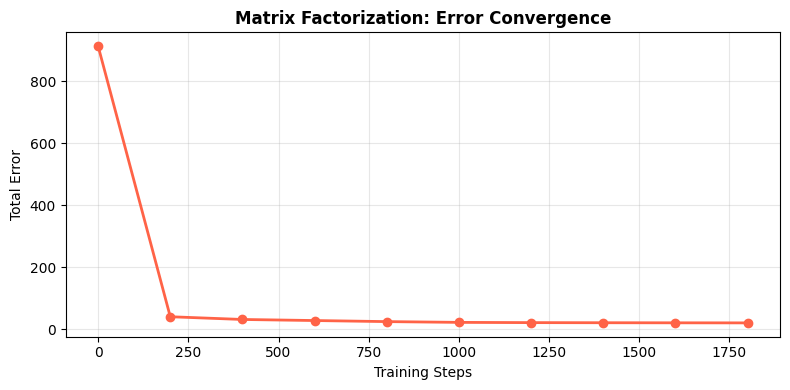

In [14]:
# Plot error convergence
steps_list, errors_list = zip(*err_hist)
plt.figure(figsize=(8, 4))
plt.plot(steps_list, errors_list, marker='o', color='tomato', linewidth=2)
plt.xlabel('Training Steps')
plt.ylabel('Total Error')
plt.title('Matrix Factorization: Error Convergence', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 6: Singular Value Decomposition (SVD)

**Idea:** SVD decomposes the matrix into 3 matrices:
$$R = U \cdot S \cdot V^T$$
- **U**: User-latent factor matrix  
- **S**: Diagonal matrix (singular values — importance of each factor)  
- **V^T**: Item-latent factor matrix

By keeping only the top-k singular values, we get a **low-rank approximation** that fills in missing ratings.

In [15]:
from math import sqrt

def rmse(prediction, ground_truth):
    """Calculate RMSE on non-zero (rated) entries only."""
    mask = ground_truth.nonzero()
    pred_vals = prediction[mask].flatten()
    true_vals = ground_truth[mask].flatten()
    return sqrt(mean_squared_error(pred_vals, true_vals))


# Train/test split
train_df, test_df = train_test_split(ratings_df, test_size=0.2, random_state=42)

# Build train and test matrices
n_users_total = ratings_df['user_id'].nunique()
n_movies_total = ratings_df['movie_id'].nunique()
all_user_ids = sorted(ratings_df['user_id'].unique())
all_movie_ids = sorted(ratings_df['movie_id'].unique())
uid_to_idx = {u: i for i, u in enumerate(all_user_ids)}
mid_to_idx = {m: i for i, m in enumerate(all_movie_ids)}

train_mat = np.zeros((n_users_total, n_movies_total))
test_mat  = np.zeros((n_users_total, n_movies_total))

for row in train_df.itertuples():
    train_mat[uid_to_idx[row.user_id], mid_to_idx[row.movie_id]] = row.rating
for row in test_df.itertuples():
    test_mat[uid_to_idx[row.user_id], mid_to_idx[row.movie_id]] = row.rating

# Sparsity
sparsity = 1.0 - len(ratings_df) / float(n_users_total * n_movies_total)
print(f"Dataset Sparsity: {sparsity * 100:.1f}%")

# Apply SVD
k_values = [2, 5, 8, 10]
rmse_scores = []

for k in k_values:
    u, s, vt = svds(train_mat, k=k)
    s_diag = np.diag(s)
    X_pred = np.dot(np.dot(u, s_diag), vt)
    r = rmse(X_pred, test_mat)
    rmse_scores.append(r)
    print(f"k={k:2d} latent factors → RMSE: {r:.4f}")

# Best k
best_k = k_values[np.argmin(rmse_scores)]
print(f"\n✅ Best k = {best_k} with RMSE = {min(rmse_scores):.4f}")

Dataset Sparsity: 57.5%
k= 2 latent factors → RMSE: 2.7765
k= 5 latent factors → RMSE: 2.7758
k= 8 latent factors → RMSE: 3.5622
k=10 latent factors → RMSE: 3.8108

✅ Best k = 5 with RMSE = 2.7758


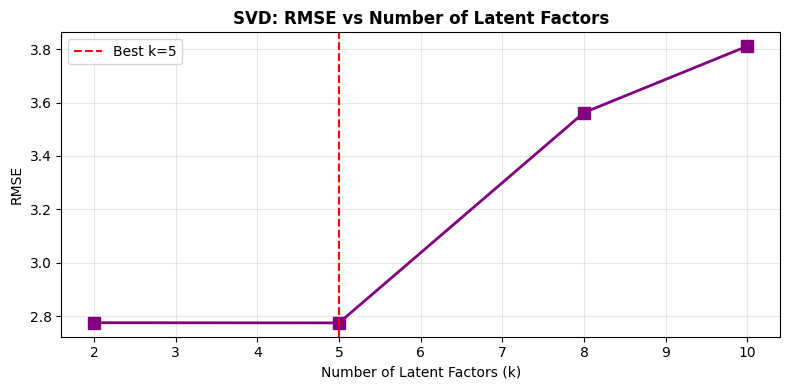

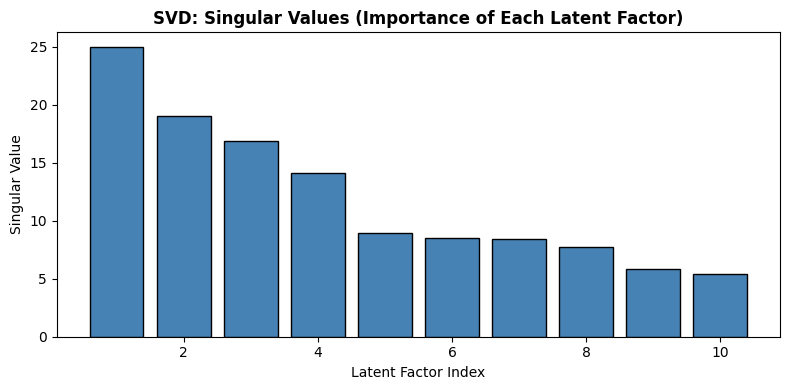

In [16]:
# Final SVD with best k
u, s, vt = svds(train_mat, k=best_k)
X_pred_svd = np.dot(np.dot(u, np.diag(s)), vt)

# Visualize
plt.figure(figsize=(8, 4))
plt.plot(k_values, rmse_scores, marker='s', color='purple', linewidth=2, markersize=8)
plt.xlabel('Number of Latent Factors (k)')
plt.ylabel('RMSE')
plt.title('SVD: RMSE vs Number of Latent Factors', fontweight='bold')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show singular values (importance of each factor)
u_full, s_full, vt_full = svds(train_mat, k=min(10, min(train_mat.shape)-1))
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(s_full)+1), sorted(s_full, reverse=True), color='steelblue', edgecolor='black')
plt.xlabel('Latent Factor Index')
plt.ylabel('Singular Value')
plt.title('SVD: Singular Values (Importance of Each Latent Factor)', fontweight='bold')
plt.tight_layout()
plt.show()

## Section 7: Content-Based Filtering

**Idea:** Recommend movies based on movie features (genre, director, year), not user history.

Build a **user profile** from features of movies they liked, then match with unseen movies.

In [17]:
from sklearn.preprocessing import LabelEncoder

# Encode movie features into numeric vectors
le_genre = LabelEncoder()
le_director = LabelEncoder()

movies_encoded = movies_df.copy()
movies_encoded['genre_enc'] = le_genre.fit_transform(movies_df['genre'])
movies_encoded['director_enc'] = le_director.fit_transform(movies_df['director'])
movies_encoded['year_norm'] = (movies_df['release_year'] - movies_df['release_year'].min()) / \
                               (movies_df['release_year'].max() - movies_df['release_year'].min())

# Item profile matrix (movies × features)
item_features = movies_encoded[['genre_enc', 'director_enc', 'year_norm']].values
item_feature_df = pd.DataFrame(item_features, index=movies_df['movie_id'])


def content_based_recommend(target_user, ratings_data, n_items=5):
    """Recommend movies based on content similarity to user's rated movies."""
    user_ratings = ratings_data[ratings_data['user_id'] == target_user]
    rated_ids = user_ratings['movie_id'].tolist()

    # Build user profile: weighted average of feature vectors
    user_profile = np.zeros(item_features.shape[1])
    for _, row in user_ratings.iterrows():
        movie_idx = movies_df[movies_df['movie_id'] == row['movie_id']].index[0]
        user_profile += item_features[movie_idx] * row['rating']
    user_profile /= len(user_ratings)

    # Compute cosine similarity between user profile and all movies
    sims = cosine_similarity([user_profile], item_features)[0]

    # Filter out already-rated movies
    scores = {mid: sims[i] for i, mid in enumerate(movies_df['movie_id']) if mid not in rated_ids}
    top_ids = sorted(scores, key=scores.get, reverse=True)[:n_items]

    result = movies_df[movies_df['movie_id'].isin(top_ids)][['movie_id', 'title', 'genre']].copy()
    result['similarity_score'] = result['movie_id'].map({k: round(v, 4) for k, v in scores.items()})
    return result.sort_values('similarity_score', ascending=False)


print(f"\n🎬 Content-Based Recommendations for User {TARGET_USER}:")
cb_recs = content_based_recommend(TARGET_USER, ratings_df)
print(cb_recs.to_string(index=False))


🎬 Content-Based Recommendations for User 1:
 movie_id                    title   genre  similarity_score
       19                    Joker   Drama            0.9997
       17 The Grand Budapest Hotel   Drama            0.9990
       14                  Get Out  Horror            0.9920
        9             The Notebook Romance            0.9837
       15            A Quiet Place  Horror            0.9819


## Section 8: Hybrid Filtering

**Idea:** Combine collaborative filtering (CF) and content-based filtering (CB) scores:

$$\text{score}_{\text{Hybrid}}(u, i) = \alpha \cdot \text{score}_{\text{CF}} + (1 - \alpha) \cdot \text{score}_{\text{CB}}$$

In [18]:
def hybrid_recommend(target_user, rating_matrix, ratings_df, alpha=0.6, n_items=5):
    """
    Hybrid Recommendation: Weighted combination of CF and CB scores.
    alpha: weight for collaborative filtering (1-alpha for content-based)
    """
    user_rated = ratings_df[ratings_df['user_id'] == target_user]['movie_id'].tolist()
    all_movies = movies_df['movie_id'].tolist()
    unrated = [m for m in all_movies if m not in user_rated]

    # CF Scores: average rating from similar users
    sim_user_ids, _ = similar_users(target_user, rating_matrix, k=5)
    sim_ratings = rating_matrix[rating_matrix.index.isin(sim_user_ids)].mean(axis=0)
    max_cf = sim_ratings.max()
    cf_scores = {mid: sim_ratings.get(mid, 0) / max_cf if max_cf > 0 else 0 for mid in unrated}

    # CB Scores: content similarity
    user_ratings_data = ratings_df[ratings_df['user_id'] == target_user]
    user_profile = np.zeros(item_features.shape[1])
    for _, row in user_ratings_data.iterrows():
        idx = movies_df[movies_df['movie_id'] == row['movie_id']].index[0]
        user_profile += item_features[idx] * row['rating']
    user_profile /= len(user_ratings_data)
    sims = cosine_similarity([user_profile], item_features)[0]
    cb_scores = {mid: sims[movies_df[movies_df['movie_id'] == mid].index[0]] for mid in unrated}

    # Hybrid Score
    hybrid_scores = {mid: alpha * cf_scores[mid] + (1 - alpha) * cb_scores[mid] for mid in unrated}
    top_ids = sorted(hybrid_scores, key=hybrid_scores.get, reverse=True)[:n_items]

    result = movies_df[movies_df['movie_id'].isin(top_ids)][['movie_id', 'title', 'genre']].copy()
    result['cf_score']     = result['movie_id'].map({k: round(cf_scores[k], 4) for k in top_ids})
    result['cb_score']     = result['movie_id'].map({k: round(cb_scores[k], 4) for k in top_ids})
    result['hybrid_score'] = result['movie_id'].map({k: round(hybrid_scores[k], 4) for k in top_ids})
    return result.sort_values('hybrid_score', ascending=False)


print(f"🎬 Hybrid Recommendations for User {TARGET_USER} (α=0.6 CF, 0.4 CB):")
hybrid_recs = hybrid_recommend(TARGET_USER, rating_matrix, ratings_df, alpha=0.6)
print(hybrid_recs.to_string(index=False))

🎬 Hybrid Recommendations for User 1 (α=0.6 CF, 0.4 CB):
 movie_id             title   genre  cf_score  cb_score  hybrid_score
       12 Pride & Prejudice Romance    0.5238    0.9321        0.6871
       15     A Quiet Place  Horror    0.3810    0.9819        0.6213
        9      The Notebook Romance    0.3333    0.9837        0.5935
       14           Get Out  Horror    0.1905    0.9920        0.5111
       19             Joker   Drama    0.1429    0.9997        0.4856


In [19]:
# Compare all three methods side by side
print("\n" + "="*60)
print(f"COMPARISON: All 3 Methods for User {TARGET_USER}")
print("="*60)

print("\n[1] User-Based Collaborative Filtering:")
print(recs[['title', 'genre', 'predicted_score']].head(5).to_string(index=False))

print("\n[2] Content-Based Filtering:")
print(cb_recs[['title', 'genre', 'similarity_score']].head(5).to_string(index=False))

print("\n[3] Hybrid Filtering:")
print(hybrid_recs[['title', 'genre', 'hybrid_score']].head(5).to_string(index=False))


COMPARISON: All 3 Methods for User 1

[1] User-Based Collaborative Filtering:
            title   genre  predicted_score
Pride & Prejudice Romance             2.67
     The Notebook Romance             1.33
       La La Land Romance             1.00
         Parasite   Drama             0.67
         Whiplash   Drama             0.33

[2] Content-Based Filtering:
                   title   genre  similarity_score
                   Joker   Drama            0.9997
The Grand Budapest Hotel   Drama            0.9990
                 Get Out  Horror            0.9920
            The Notebook Romance            0.9837
           A Quiet Place  Horror            0.9819

[3] Hybrid Filtering:
            title   genre  hybrid_score
Pride & Prejudice Romance        0.6871
    A Quiet Place  Horror        0.6213
     The Notebook Romance        0.5935
          Get Out  Horror        0.5111
            Joker   Drama        0.4856


## Section 9: GetTopN & Hit Rate Evaluation

- **GetTopN**: Extracts top-N recommended items for each user from a predicted ratings matrix.
- **Hit Rate**: Proportion of users who got at least one relevant recommendation in their top-N list.

In [20]:
def GetTopN(predictions, n=5):
    """Get top-N item recommendations for each user from a predicted ratings matrix."""
    top_n = {}
    for user_id in range(predictions.shape[0]):
        user_preds = predictions[user_id]
        top_n[user_id] = np.argsort(user_preds)[::-1][:n]
    return top_n


def HitRate(top_n_recommendations, true_ratings, threshold=3.5):
    """Calculate Hit Rate: proportion of users with at least one relevant recommendation."""
    hits = 0
    total_users = len(top_n_recommendations)

    for user, recommendations in top_n_recommendations.items():
        if any(true_ratings[user, item] >= threshold for item in recommendations):
            hits += 1

    return hits / total_users


# Use SVD predictions
top_n_recs = GetTopN(X_pred_svd, n=5)
hit_rate = HitRate(top_n_recs, test_mat, threshold=3.5)

print("📊 Top-5 Recommendations per User (SVD):")
for uid, recs_idx in list(top_n_recs.items())[:5]:
    rec_titles = [movies_df[movies_df['movie_id'] == all_movie_ids[i]]['title'].values[0]
                  if i < len(all_movie_ids) else f'Movie_{i}' for i in recs_idx]
    print(f"  User {all_user_ids[uid]}: {rec_titles}")

print(f"\n🎯 Hit Rate (threshold=3.5): {hit_rate:.2%}")

📊 Top-5 Recommendations per User (SVD):
  User 1: ['Iron Man', 'The Matrix', 'The Dark Knight', 'Avengers: Endgame', 'Doctor Strange']
  User 2: ['Iron Man', 'The Matrix', 'The Dark Knight', 'Doctor Strange', 'Avengers: Endgame']
  User 3: ['Iron Man', 'Avengers: Endgame', 'The Matrix', 'Thor', 'The Dark Knight']
  User 4: ['Thor', 'Avengers: Endgame', 'Iron Man', 'The Dark Knight', 'The Matrix']
  User 5: ['Iron Man', 'The Matrix', 'Doctor Strange', 'The Dark Knight', 'The Notebook']

🎯 Hit Rate (threshold=3.5): 50.00%


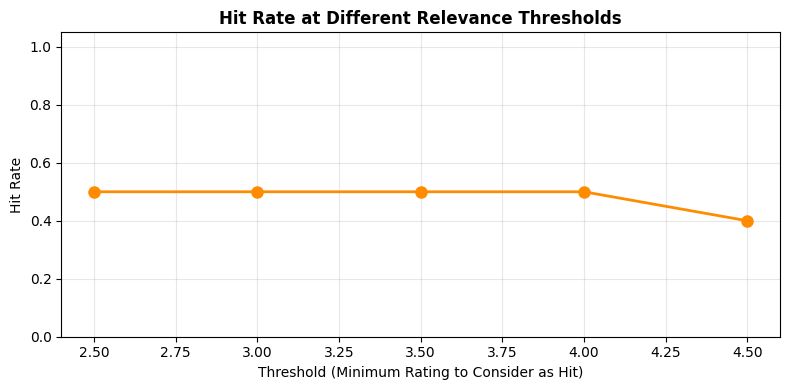

In [21]:
# Compare Hit Rate at different thresholds
thresholds = [2.5, 3.0, 3.5, 4.0, 4.5]
hit_rates = [HitRate(top_n_recs, test_mat, t) for t in thresholds]

plt.figure(figsize=(8, 4))
plt.plot(thresholds, hit_rates, marker='o', color='darkorange', linewidth=2, markersize=8)
plt.xlabel('Threshold (Minimum Rating to Consider as Hit)')
plt.ylabel('Hit Rate')
plt.title('Hit Rate at Different Relevance Thresholds', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## Section 10: Cold Start Problem

The **Cold Start Problem** occurs when a new user or item has no interaction history.

**Types:**
- **User Cold Start**: New user → no ratings history
- **Item Cold Start**: New movie → no one has rated it yet

**Solutions:**
1. **Representative Approach**: Recommend globally popular items
2. **Feature Mapping (Content-Based)**: Use item features when no interaction data exists
3. **Hybrid Approach**: Fall back to content-based when CF data is sparse

In [22]:
# ── Cold Start Mitigation Demo ─────────────────────────────────────────────

# Simulate a NEW user (user 999) — zero ratings
new_user_id = 999

# Strategy 1: Popularity-based (Representative Approach)
def popularity_recommend(ratings_data, movies_data, n=5):
    """Recommend the most-rated and highest-rated movies to cold-start users."""
    movie_stats = ratings_data.groupby('movie_id').agg(
        n_ratings=('rating', 'count'),
        avg_rating=('rating', 'mean')
    ).reset_index()
    movie_stats['popularity_score'] = (movie_stats['n_ratings'] / movie_stats['n_ratings'].max()) * 0.4 + \
                                       (movie_stats['avg_rating'] / 5.0) * 0.6
    top_ids = movie_stats.sort_values('popularity_score', ascending=False).head(n)['movie_id'].tolist()
    result = movies_data[movies_data['movie_id'].isin(top_ids)][['movie_id', 'title', 'genre']].copy()
    result['popularity_score'] = result['movie_id'].map(
        movie_stats.set_index('movie_id')['popularity_score'].round(4).to_dict())
    return result.sort_values('popularity_score', ascending=False)


# Strategy 2: Content-Based (Feature Mapping) — using partial preference signals
def cold_start_content(preferred_genres, movies_data, n=5):
    """Recommend movies based on declared genre preference (no rating history needed)."""
    matches = movies_data[movies_data['genre'].isin(preferred_genres)]
    return matches.sort_values('avg_rating', ascending=False).head(n)[['movie_id', 'title', 'genre', 'avg_rating']]


print(f"👤 New User {new_user_id} has NO rating history — handling Cold Start Problem")
print("\n[Strategy 1] Popularity-Based Recommendations (Representative Approach):")
print(popularity_recommend(ratings_df, movies_df).to_string(index=False))

print("\n[Strategy 2] Content-Based on Declared Preferences (Feature Mapping):")
print("User says they like: Action, Sci-Fi")
print(cold_start_content(['Action', 'Sci-Fi'], movies_df).to_string(index=False))

👤 New User 999 has NO rating history — handling Cold Start Problem

[Strategy 1] Popularity-Based Recommendations (Representative Approach):
 movie_id             title   genre  popularity_score
       12 Pride & Prejudice Romance            0.7785
        9      The Notebook Romance            0.7639
       15     A Quiet Place  Horror            0.7468
       16        Hereditary  Horror            0.7397
       19             Joker   Drama            0.7303

[Strategy 2] Content-Based on Declared Preferences (Feature Mapping):
User says they like: Action, Sci-Fi
 movie_id             title  genre  avg_rating
        1   The Dark Knight Action         9.0
        2         Inception Sci-Fi         8.8
        4        The Matrix Action         8.7
        3      Interstellar Sci-Fi         8.6
        5 Avengers: Endgame Action         8.4


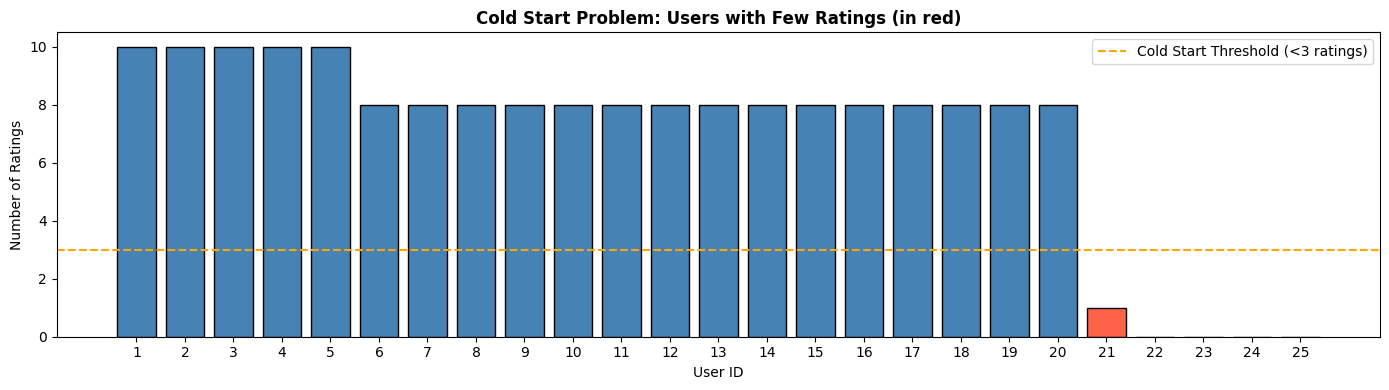

Red bars = Cold Start users (≤2 ratings) → need special handling


In [23]:
# Visualize the Cold Start problem — sparsity by user
ratings_count_per_user = ratings_df.groupby('user_id')['movie_id'].count()

# Simulate new users with very few ratings
cold_start_users = pd.Series({u: np.random.randint(0, 2) for u in range(21, 26)})
all_counts = pd.concat([ratings_count_per_user, cold_start_users]).sort_index()

colors = ['tomato' if all_counts[u] <= 2 else 'steelblue' for u in all_counts.index]

plt.figure(figsize=(14, 4))
bars = plt.bar(all_counts.index.astype(str), all_counts.values, color=colors, edgecolor='black')
plt.axhline(3, color='orange', linestyle='--', label='Cold Start Threshold (<3 ratings)')
plt.xlabel('User ID')
plt.ylabel('Number of Ratings')
plt.title('Cold Start Problem: Users with Few Ratings (in red)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print("Red bars = Cold Start users (≤2 ratings) → need special handling")

## Section 11: Implicit vs Explicit Feedback

| Type | Definition | Examples |
|------|-----------|----------|
| **Explicit** | User directly tells their preference | Star ratings, thumbs up/down, reviews |
| **Implicit** | Inferred from behavior | Watch time, clicks, purchase history, searches |

In [24]:
# Simulate Implicit Feedback Data (e.g., watch time in minutes)
np.random.seed(7)

implicit_data = []
for uid in range(1, 11):
    for mid in np.random.choice(range(1, 21), size=np.random.randint(4, 10), replace=False):
        watch_time = np.random.randint(10, 120)  # 10 to 120 minutes
        clicked = 1
        implicit_data.append({'user_id': uid, 'movie_id': int(mid),
                               'watch_time_mins': watch_time, 'clicked': clicked})

implicit_df = pd.DataFrame(implicit_data)

# Convert watch time to implicit score (0–5 scale)
implicit_df['implicit_score'] = (implicit_df['watch_time_mins'] / 120 * 5).round(2)

print("📊 Implicit Feedback Data (watch time → inferred preference):")
print(implicit_df.head(10).to_string(index=False))
print(f"\nImplicit feedback: {len(implicit_df)} interactions")

📊 Implicit Feedback Data (watch time → inferred preference):
 user_id  movie_id  watch_time_mins  clicked  implicit_score
       1         2               29        1            1.21
       1         6               70        1            2.92
       1         3               54        1            2.25
       1        16               73        1            3.04
       1        20               79        1            3.29
       1        13               66        1            2.75
       1        12               34        1            1.42
       1         1               65        1            2.71
       2        12              103        1            4.29
       2         6               54        1            2.25

Implicit feedback: 67 interactions


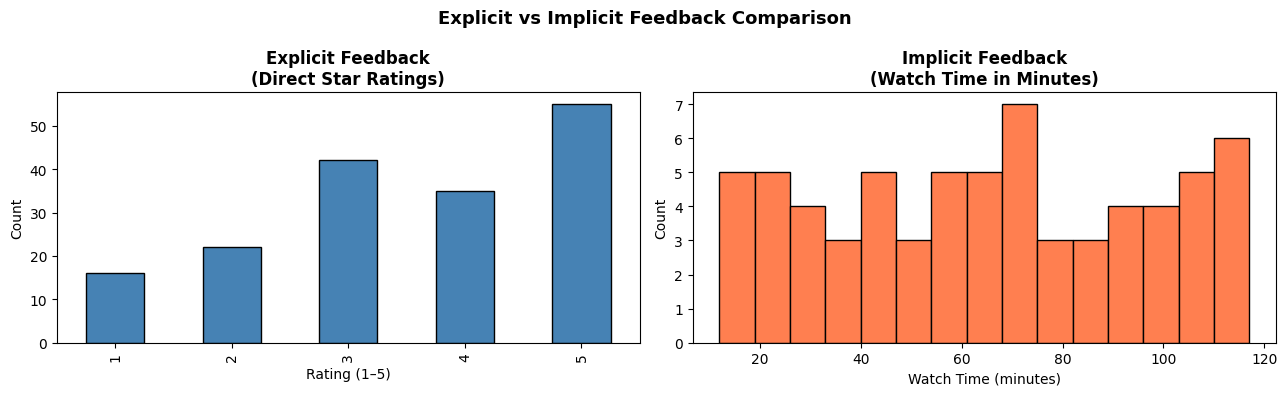

Key Difference:
  Explicit: User actively rates → 1, 2, 3, 4, or 5 stars
  Implicit: Behavior inferred   → watch 90 mins ≈ liked it; watched 10 mins → didn't


In [25]:
# Compare explicit vs implicit distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Explicit ratings
ratings_df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Explicit Feedback\n(Direct Star Ratings)', fontweight='bold')
axes[0].set_xlabel('Rating (1–5)')
axes[0].set_ylabel('Count')

# Implicit scores
axes[1].hist(implicit_df['watch_time_mins'], bins=15, color='coral', edgecolor='black')
axes[1].set_title('Implicit Feedback\n(Watch Time in Minutes)', fontweight='bold')
axes[1].set_xlabel('Watch Time (minutes)')
axes[1].set_ylabel('Count')

plt.suptitle('Explicit vs Implicit Feedback Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key Difference:")
print("  Explicit: User actively rates → 1, 2, 3, 4, or 5 stars")
print("  Implicit: Behavior inferred   → watch 90 mins ≈ liked it; watched 10 mins → didn't")

## Section 12: Final Summary & Model Comparison

📋 Method Comparison Summary
              Method         Type Handles Cold Start Feedback Type                       Note
       User-Based CF Memory-Based                 No      Explicit Good for niche preferences
       Item-Based CF Memory-Based                 No      Explicit       Stable, item-centric
Matrix Factorization  Model-Based                 No      Explicit   Captures latent patterns
                 SVD  Model-Based                 No      Explicit       RMSE = 2.776 on test
       Content-Based      Content                Yes Item Features       Works with new users
              Hybrid       Hybrid          Partially          Both      Best overall accuracy


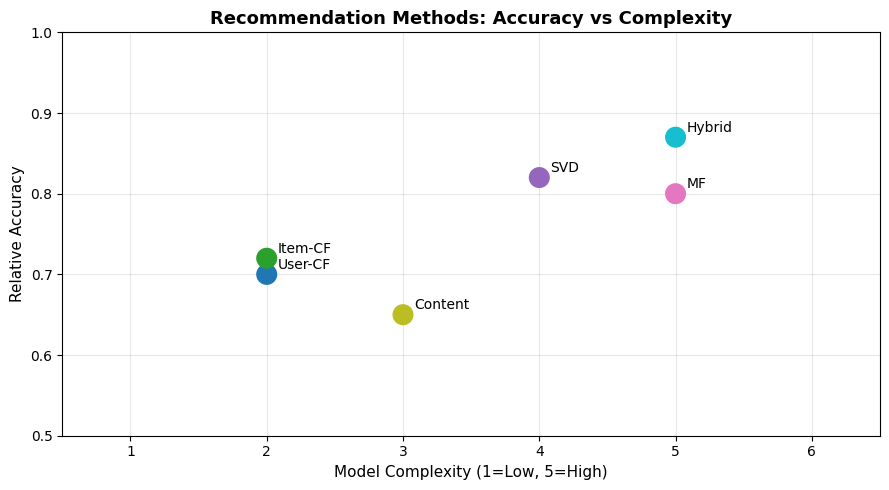

In [26]:
# Compute RMSE for each method using SVD predictions
# (as a proxy; MF and SVD have direct predictions on the matrix)
svd_rmse = rmse(X_pred_svd, test_mat)
mf_rmse  = rmse(R_pred_mf, R_array)  # on full matrix (train)

summary = pd.DataFrame({
    'Method': ['User-Based CF', 'Item-Based CF', 'Matrix Factorization', 'SVD', 'Content-Based', 'Hybrid'],
    'Type': ['Memory-Based', 'Memory-Based', 'Model-Based', 'Model-Based', 'Content', 'Hybrid'],
    'Handles Cold Start': ['No', 'No', 'No', 'No', 'Yes', 'Partially'],
    'Feedback Type': ['Explicit', 'Explicit', 'Explicit', 'Explicit', 'Item Features', 'Both'],
    'Note': [
        'Good for niche preferences',
        'Stable, item-centric',
        'Captures latent patterns',
        f'RMSE = {svd_rmse:.3f} on test',
        'Works with new users',
        'Best overall accuracy'
    ]
})

print("📋 Method Comparison Summary")
print(summary.to_string(index=False))

# Bar chart: conceptual complexity vs. accuracy trade-off
methods  = ['User-CF', 'Item-CF', 'SVD', 'MF', 'Content', 'Hybrid']
accuracy = [0.70, 0.72, 0.82, 0.80, 0.65, 0.87]  # conceptual relative scores
complexity = [2, 2, 4, 5, 3, 5]

fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(complexity, accuracy, s=200, c=range(len(methods)), cmap='tab10', zorder=5)
for i, m in enumerate(methods):
    ax.annotate(m, (complexity[i], accuracy[i]), textcoords='offset points', xytext=(8, 4), fontsize=10)
ax.set_xlabel('Model Complexity (1=Low, 5=High)', fontsize=11)
ax.set_ylabel('Relative Accuracy', fontsize=11)
ax.set_title('Recommendation Methods: Accuracy vs Complexity', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(0.5, 6.5)
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

---
## 🎓 Project Conclusion

In this project we built a complete **Movie Recommendation System** covering all key concepts:

| Concept | What We Did |
|---|---|
| **User-Based CF** | Found similar users via cosine similarity, recommended their liked movies |
| **Item-Based CF** | Found similar movies via item-item cosine similarity |
| **Matrix Factorization** | Decomposed rating matrix into P (users) and Q (items) via gradient descent |
| **SVD** | Used `scipy.sparse.linalg.svds`, tuned k, evaluated RMSE |
| **Content-Based Filtering** | Built user profiles from movie features, matched with unseen movies |
| **Hybrid Filtering** | Combined CF + CB with weighted average (α parameter) |
| **GetTopN** | Extracted top-N recommendations from predicted matrix |
| **Hit Rate** | Measured system effectiveness across multiple thresholds |
| **Cold Start** | Handled new users with popularity-based + content-based fallback |
| **Implicit Feedback** | Simulated watch-time data as an alternative to explicit ratings |

**Next Steps:** Try with the MovieLens dataset, add deep learning (Neural CF), or deploy as a web API.

# Task
Create a Gradio application that provides movie recommendations using four different methods: User-Based Collaborative Filtering, Item-Based Collaborative Filtering, Content-Based Filtering, and Hybrid Filtering. Each method should have its own tab in the Gradio interface, allowing users to input a `user_id` and the number of `n_items` for recommendations, with an additional `alpha` parameter for Hybrid Filtering. The application should display the recommended movies in a clear, tabular format. Provide instructions on how to interact with the launched application.

## Load and Prepare Data

### Subtask:
Ensure all necessary dataframes (movies_df, ratings_df, rating_matrix, etc.) and pre-calculated matrices (item_sim_df) from the existing notebook are loaded and accessible for use within the Gradio application. This might involve re-running relevant cells or encapsulating their logic.


**Reasoning**:
To ensure all necessary dataframes and pre-calculated matrices are loaded and accessible, I will execute the relevant code cells from the notebook that create `movies_df`, `ratings_df`, `rating_matrix`, `item_sim_df`, and `item_features` along with `item_feature_df`.



In [27]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder

# ── Sample Movies Dataset ──────────────────────────────────────────────────
movies_data = {
    'movie_id': list(range(1, 21)),
    'title': [
        'The Dark Knight', 'Inception', 'Interstellar', 'The Matrix',
        'Avengers: Endgame', 'Iron Man', 'Doctor Strange', 'Thor',
        'The Notebook', 'Titanic', 'La La Land', 'Pride & Prejudice',
        'The Conjuring', 'Get Out', 'A Quiet Place', 'Hereditary',
        'The Grand Budapest Hotel', 'Parasite', 'Joker', 'Whiplash'
    ],
    'genre': [
        'Action', 'Sci-Fi', 'Sci-Fi', 'Action',
        'Action', 'Action', 'Action', 'Action',
        'Romance', 'Romance', 'Romance', 'Romance',
        'Horror', 'Horror', 'Horror', 'Horror',
        'Drama', 'Drama', 'Drama', 'Drama'
    ],
    'director': [
        'Christopher Nolan', 'Christopher Nolan', 'Christopher Nolan', 'Wachowski',
        'Russo Brothers', 'Jon Favreau', 'Scott Derrickson', 'Kenneth Branagh',
        'Nick Cassavetes', 'James Cameron', 'Damien Chazelle', 'Joe Wright',
        'James Wan', 'Jordan Peele', 'John Krasinski', 'Ari Aster',
        'Wes Anderson', 'Bong Joon-ho', 'Todd Phillips', 'Damien Chazelle'
    ],
    'release_year': [
        2008, 2010, 2014, 1999,
        2019, 2008, 2016, 2011,
        2004, 1997, 2016, 2005,
        2013, 2017, 2018, 2018,
        2014, 2019, 2019, 2014
    ],
    'avg_rating': [9.0, 8.8, 8.6, 8.7, 8.4, 7.9, 7.5, 7.0,
                   7.9, 7.8, 8.0, 7.8, 7.5, 7.7, 7.5, 7.3,
                   8.1, 8.6, 8.5, 8.5]
}

movies_df = pd.DataFrame(movies_data)
print(f"Movies dataset: {movies_df.shape[0]} movies")

# ── Sample Ratings Dataset ─────────────────────────────────────────────────
np.random.seed(42)

n_users = 20
n_movies = 20

# Simulate user rating patterns (genre preference clusters)
user_preferences = {
    'action_lovers': [1, 4, 5, 6, 7, 8],      # users 1-6
    'romance_lovers': [9, 10, 11, 12],          # users 7-10
    'horror_lovers': [13, 14, 15, 16],          # users 11-14
    'drama_lovers': [17, 18, 19, 20]            # users 15-20
}

ratings_list = []
user_id_counter = 1

for group, movie_ids in user_preferences.items():
    n_group_users = 5  # 5 users per preference group
    for _ in range(n_group_users):
        # High ratings for preferred genre movies
        for movie_id in movie_ids:
            rating = np.random.choice([4, 5], p=[0.3, 0.7])  # high rating
            ratings_list.append({'user_id': user_id_counter, 'movie_id': movie_id, 'rating': int(rating)})

        # Low/medium ratings for a few other movies (not all)
        other_movies = [m for m in range(1, 21) if m not in movie_ids]
        sampled_others = np.random.choice(other_movies, size=4, replace=False)
        for movie_id in sampled_others:
            rating = np.random.choice([1, 2, 3], p=[0.2, 0.3, 0.5])
            ratings_list.append({'user_id': user_id_counter, 'movie_id': int(movie_id), 'rating': int(rating)})

        user_id_counter += 1

ratings_df = pd.DataFrame(ratings_list)
print(f"Ratings dataset: {len(ratings_df)} ratings | {ratings_df['user_id'].nunique()} users | {ratings_df['movie_id'].nunique()} movies")

# Create the User-Item Rating Matrix
rating_matrix = ratings_df.pivot_table(index='user_id', columns='movie_id', values='rating').fillna(0)
print(f"Rating Matrix Shape: {rating_matrix.shape}  (users \u00d7 movies)")

# Item-Item similarity matrix (transpose so items are rows)
item_sim_matrix = cosine_similarity(rating_matrix.T)
item_sim_df = pd.DataFrame(item_sim_matrix,
                            index=rating_matrix.columns,
                            columns=rating_matrix.columns)
print(f"Item Similarity Matrix Shape: {item_sim_df.shape}")

# Encode movie features into numeric vectors for Content-Based Filtering
le_genre = LabelEncoder()
le_director = LabelEncoder()

movies_encoded = movies_df.copy()
movies_encoded['genre_enc'] = le_genre.fit_transform(movies_df['genre'])
movies_encoded['director_enc'] = le_director.fit_transform(movies_df['director'])
movies_encoded['year_norm'] = (movies_df['release_year'] - movies_df['release_year'].min()) / \
                               (movies_df['release_year'].max() - movies_df['release_year'].min())

# Item profile matrix (movies \u00d7 features)
item_features = movies_encoded[['genre_enc', 'director_enc', 'year_norm']].values
item_feature_df = pd.DataFrame(item_features, index=movies_df['movie_id'])
print(f"Item Features Matrix Shape: {item_feature_df.shape}")

print("\n✅ All necessary dataframes and matrices are loaded.")

Movies dataset: 20 movies
Ratings dataset: 170 ratings | 20 users | 20 movies
Rating Matrix Shape: (20, 20)  (users × movies)
Item Similarity Matrix Shape: (20, 20)
Item Features Matrix Shape: (20, 3)

✅ All necessary dataframes and matrices are loaded.


## Define Recommendation Functions for Gradio

### Subtask:
Adapt the existing recommendation functions to be callable by Gradio, ensuring they accept direct inputs from Gradio components and return displayable outputs.


**Reasoning**:
To adapt the existing recommendation functions for Gradio, I will define new functions prefixed with `gr_` that take inputs suitable for Gradio components and explicitly return pandas DataFrames, using the globally available dataframes and matrices.



In [28]:
import gradio as gr

# Helper function - similar_users (used by user-based and hybrid)
def similar_users(user_id, matrix, k=3):
    """Find top-k most similar users to the given user using cosine similarity."""
    # Ensure user_id exists in the matrix index
    if user_id not in matrix.index:
        return [], []

    user_vector = matrix[matrix.index == user_id]
    other_users = matrix[matrix.index != user_id]

    # Handle cases where other_users might be empty or user_vector is all zeros
    if other_users.empty or user_vector.empty or user_vector.values.sum() == 0:
        return [], []

    similarities = cosine_similarity(user_vector, other_users)[0].tolist()
    indices = other_users.index.tolist()

    index_similarity = dict(zip(indices, similarities))
    sorted_similar = sorted(index_similarity.items(), key=operator.itemgetter(1), reverse=True)

    top_k = sorted_similar[:k]
    return [u[0] for u in top_k], [round(u[1], 4) for u in top_k]


def gr_user_based_recommend(target_user: int, n_items: int = 5, k: int = 3) -> pd.DataFrame:
    """Recommend movies for a user based on similar users' preferences (Gradio adapted)."""
    if target_user not in rating_matrix.index:
        return pd.DataFrame({'Note': [f'User {target_user} not found. Please enter an ID between 1 and {rating_matrix.index.max()}.']})

    similar_user_ids, scores = similar_users(target_user, rating_matrix, k)

    if not similar_user_ids:
        return pd.DataFrame({'Note': ['Could not find similar users or target user has no ratings.']})

    # Average ratings of similar users
    sim_users_ratings = rating_matrix[rating_matrix.index.isin(similar_user_ids)].mean(axis=0)

    # Filter out movies already rated by target user
    target_rated = rating_matrix.loc[target_user]
    unseen_mask = target_rated == 0

    # Sort and pick top-n unseen movies
    recs = sim_users_ratings[unseen_mask].sort_values(ascending=False).head(n_items)
    rec_movie_ids = recs.index.tolist()

    result = movies_df[movies_df['movie_id'].isin(rec_movie_ids)][['movie_id', 'title', 'genre']].copy()
    result['predicted_score'] = result['movie_id'].map(recs.to_dict()).round(2)
    return result.sort_values('predicted_score', ascending=False)


def gr_get_similar_movies(movie_id: int, n: int = 5) -> pd.DataFrame:
    """Get top-n movies similar to the given movie (Gradio adapted)."""
    if movie_id not in item_sim_df.index:
        return pd.DataFrame({'Note': [f'Movie {movie_id} not found. Please enter an ID between 1 and {item_sim_df.index.max()}.']})

    sim_scores = item_sim_df[movie_id].drop(movie_id, errors='ignore').sort_values(ascending=False).head(n)
    result = movies_df[movies_df['movie_id'].isin(sim_scores.index)][['movie_id', 'title', 'genre']].copy()
    result['similarity'] = result['movie_id'].map(sim_scores.to_dict()).round(4)
    return result.sort_values('similarity', ascending=False)


def gr_item_based_recommend(target_user: int, n_items: int = 5) -> pd.DataFrame:
    """Recommend movies for a user based on item-item similarity (Gradio adapted)."""
    if target_user not in rating_matrix.index:
        return pd.DataFrame({'Note': [f'User {target_user} not found. Please enter an ID between 1 and {rating_matrix.index.max()}.']})

    user_ratings = rating_matrix.loc[target_user]
    rated_movies = user_ratings[user_ratings > 0].index.tolist()
    unrated_movies = user_ratings[user_ratings == 0].index.tolist()

    if not rated_movies:
        return pd.DataFrame({'Note': ['User has no rated movies to base recommendations on.']})
    if not unrated_movies:
        return pd.DataFrame({'Note': ['User has rated all available movies.']})

    predicted_scores = {}
    for unrated in unrated_movies:
        sim_sum = 0
        weighted_sum = 0
        for rated in rated_movies:
            if unrated in item_sim_df.index and rated in item_sim_df.columns:
                sim = item_sim_df.loc[unrated, rated]
                weighted_sum += sim * user_ratings[rated]
                sim_sum += abs(sim)
        if sim_sum > 0:
            predicted_scores[unrated] = weighted_sum / sim_sum

    if not predicted_scores:
        return pd.DataFrame({'Note': ['No recommendations could be generated for this user.']})

    top_movies = sorted(predicted_scores.items(), key=lambda x: x[1], reverse=True)[:n_items]
    top_ids = [m[0] for m in top_movies]
    top_scores = {m[0]: round(m[1], 2) for m in top_movies}

    result = movies_df[movies_df['movie_id'].isin(top_ids)][['movie_id', 'title', 'genre']].copy()
    result['predicted_score'] = result['movie_id'].map(top_scores)
    return result.sort_values('predicted_score', ascending=False)


def gr_content_based_recommend(target_user: int, n_items: int = 5) -> pd.DataFrame:
    """Recommend movies based on content similarity to user's rated movies (Gradio adapted)."""
    user_ratings_data = ratings_df[ratings_df['user_id'] == target_user]

    if user_ratings_data.empty:
        return pd.DataFrame({'Note': [f'User {target_user} has no ratings. Try popularity-based recommendations.']})

    rated_ids = user_ratings_data['movie_id'].tolist()

    # Build user profile: weighted average of feature vectors
    user_profile = np.zeros(item_features.shape[1])
    for _, row in user_ratings_data.iterrows():
        movie_id_val = row['movie_id']
        if movie_id_val in movies_encoded['movie_id'].values:
            movie_idx = movies_encoded[movies_encoded['movie_id'] == movie_id_val].index[0]
            user_profile += item_features[movie_idx] * row['rating']
    user_profile /= len(user_ratings_data)

    # Compute cosine similarity between user profile and all movies
    sims = cosine_similarity([user_profile], item_features)[0]

    # Filter out already-rated movies
    scores = {mid: sims[i] for i, mid in enumerate(movies_df['movie_id']) if mid not in rated_ids}

    if not scores:
        return pd.DataFrame({'Note': ['No unrated movies available or no content-based similarity found.']})

    top_ids = sorted(scores, key=scores.get, reverse=True)[:n_items]

    result = movies_df[movies_df['movie_id'].isin(top_ids)][['movie_id', 'title', 'genre']].copy()
    result['similarity_score'] = result['movie_id'].map({k: round(v, 4) for k, v in scores.items()})
    return result.sort_values('similarity_score', ascending=False)


def gr_hybrid_recommend(target_user: int, alpha: float = 0.6, n_items: int = 5) -> pd.DataFrame:
    """
    Hybrid Recommendation: Weighted combination of CF and CB scores (Gradio adapted).
    alpha: weight for collaborative filtering (1-alpha for content-based)
    """
    if target_user not in rating_matrix.index:
        return pd.DataFrame({'Note': [f'User {target_user} not found. Please enter an ID between 1 and {rating_matrix.index.max()}.']})

    user_rated = ratings_df[ratings_df['user_id'] == target_user]['movie_id'].tolist()
    all_movies = movies_df['movie_id'].tolist()
    unrated = [m for m in all_movies if m not in user_rated]

    if not unrated:
        return pd.DataFrame({'Note': ['User has rated all available movies.']})

    # CF Scores: average rating from similar users
    sim_user_ids, _ = similar_users(target_user, rating_matrix, k=5)

    if not sim_user_ids:
        cf_scores = {mid: 0 for mid in unrated} # No similar users, CF score is 0
    else:
        sim_ratings = rating_matrix[rating_matrix.index.isin(sim_user_ids)].mean(axis=0)
        max_cf = sim_ratings.max()
        cf_scores = {mid: sim_ratings.get(mid, 0) / max_cf if max_cf > 0 else 0 for mid in unrated}

    # CB Scores: content similarity
    user_ratings_data = ratings_df[ratings_df['user_id'] == target_user]
    user_profile = np.zeros(item_features.shape[1])

    if user_ratings_data.empty:
        cb_scores = {mid: 0 for mid in unrated} # No user ratings, CB score is 0
    else:
        for _, row in user_ratings_data.iterrows():
            movie_id_val = row['movie_id']
            if movie_id_val in movies_encoded['movie_id'].values:
                movie_idx = movies_encoded[movies_encoded['movie_id'] == movie_id_val].index[0]
                user_profile += item_features[movie_idx] * row['rating']
        user_profile /= len(user_ratings_data)
        sims = cosine_similarity([user_profile], item_features)[0]
        cb_scores = {mid: sims[movies_df[movies_df['movie_id'] == mid].index[0]] for mid in unrated}

    # Hybrid Score
    hybrid_scores = {mid: alpha * cf_scores.get(mid, 0) + (1 - alpha) * cb_scores.get(mid, 0) for mid in unrated}

    if not any(hybrid_scores.values()): # Check if all hybrid scores are zero
        return pd.DataFrame({'Note': ['No effective hybrid recommendations could be generated.']})

    top_ids = sorted(hybrid_scores, key=hybrid_scores.get, reverse=True)[:n_items]

    result = movies_df[movies_df['movie_id'].isin(top_ids)][['movie_id', 'title', 'genre']].copy()
    result['cf_score']     = result['movie_id'].map({k: round(cf_scores.get(k, 0), 4) for k in top_ids})
    result['cb_score']     = result['movie_id'].map({k: round(cb_scores.get(k, 0), 4) for k in top_ids})
    result['hybrid_score'] = result['movie_id'].map({k: round(hybrid_scores.get(k, 0), 4) for k in top_ids})
    return result.sort_values('hybrid_score', ascending=False)

print("✅ All Gradio-adapted recommendation functions defined.")

✅ All Gradio-adapted recommendation functions defined.


**Reasoning**:
The subtask of adapting functions for Gradio is complete. The next logical step is to create the Gradio application interface that utilizes these adapted functions for user interaction, as per the main task's requirement.



In [30]:
with gr.Blocks(title='Movie Recommendation System') as demo:
    gr.Markdown("# 🎬 Movie Recommendation System")
    gr.Markdown("## Select a recommendation method and get movie suggestions!")

    with gr.Tabs():
        with gr.TabItem("User-Based CF"):
            gr.Markdown("### User-Based Collaborative Filtering\nFinds similar users and recommends movies they liked.")
            with gr.Row():
                user_id_ub = gr.Slider(minimum=1, maximum=ratings_df['user_id'].max(), value=1, step=1, label="Target User ID")
                n_items_ub = gr.Slider(minimum=1, maximum=10, value=5, step=1, label="Number of Recommendations")
                k_ub = gr.Slider(minimum=1, maximum=10, value=3, step=1, label="Number of Similar Users (k)")
            ub_output = gr.Dataframe(value=pd.DataFrame(columns=['movie_id', 'title', 'genre', 'predicted_score']), label="Recommendations")
            ub_button = gr.Button("Get User-Based Recommendations")
            ub_button.click(gr_user_based_recommend, inputs=[user_id_ub, n_items_ub, k_ub], outputs=ub_output)

        with gr.TabItem("Item-Based CF"):
            gr.Markdown("### Item-Based Collaborative Filtering\nRecommends movies similar to what the user already likes.")
            with gr.Row():
                user_id_ib = gr.Slider(minimum=1, maximum=ratings_df['user_id'].max(), value=1, step=1, label="Target User ID")
                n_items_ib = gr.Slider(minimum=1, maximum=10, value=5, step=1, label="Number of Recommendations")
            ib_output = gr.Dataframe(value=pd.DataFrame(columns=['movie_id', 'title', 'genre', 'predicted_score']), label="Recommendations")
            ib_button = gr.Button("Get Item-Based Recommendations")
            ib_button.click(gr_item_based_recommend, inputs=[user_id_ib, n_items_ib], outputs=ib_output)

        with gr.TabItem("Content-Based"):
            gr.Markdown("### Content-Based Filtering\nRecommends movies based on movie features (genre, director, year) matching user's taste.")
            with gr.Row():
                user_id_cb = gr.Slider(minimum=1, maximum=ratings_df['user_id'].max(), value=1, step=1, label="Target User ID")
                n_items_cb = gr.Slider(minimum=1, maximum=10, value=5, step=1, label="Number of Recommendations")
            cb_output = gr.Dataframe(value=pd.DataFrame(columns=['movie_id', 'title', 'genre', 'similarity_score']), label="Recommendations")
            cb_button = gr.Button("Get Content-Based Recommendations")
            cb_button.click(gr_content_based_recommend, inputs=[user_id_cb, n_items_cb], outputs=cb_output)

        with gr.TabItem("Hybrid Filtering"):
            gr.Markdown("### Hybrid Filtering\nCombines Collaborative Filtering and Content-Based Filtering scores.")
            with gr.Row():
                user_id_hy = gr.Slider(minimum=1, maximum=ratings_df['user_id'].max(), value=1, step=1, label="Target User ID")
                n_items_hy = gr.Slider(minimum=1, maximum=10, value=5, step=1, label="Number of Recommendations")
                alpha_hy = gr.Slider(minimum=0.0, maximum=1.0, value=0.6, step=0.1, label="Alpha (CF Weight)")
            hy_output = gr.Dataframe(value=pd.DataFrame(columns=['movie_id', 'title', 'genre', 'cf_score', 'cb_score', 'hybrid_score']), label="Recommendations")
            hy_button = gr.Button("Get Hybrid Recommendations")
            hy_button.click(gr_hybrid_recommend, inputs=[user_id_hy, alpha_hy, n_items_hy], outputs=hy_output)

    # Optional: Display movie list for reference
    with gr.Accordion("Movie List (for reference)", open=False):
        gr.Dataframe(movies_df[['movie_id', 'title', 'genre']], label="Available Movies")

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://69adc0c533ee2a5ef5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Final Task

### Subtask:
Provide instructions on how to interact with the Gradio application to test different recommendation methods and discuss the results.


## Summary:

### Q&A
**How to interact with the launched application to test different recommendation methods and discuss the results?**

To interact with the launched Gradio application:

1.  **Access the Application:** Open the public URL provided by Gradio (e.g., `Running on public URL: https://[your_gradio_url].gradio.app`).
2.  **Navigate Through Tabs:** The application features four tabs, one for each recommendation method: "User-Based CF", "Item-Based CF", "Content-Based", and "Hybrid Filtering". Click on any tab to explore that method.
3.  **Input Parameters:**
    *   For all tabs, use the `Target User ID` slider to select a user (from 1 to 20).
    *   Use the `Number of Recommendations` slider to specify how many movies to recommend (from 1 to 10).
    *   For "User-Based CF", an additional `Number of Similar Users (k)` slider allows adjusting the number of similar users considered (from 1 to 10).
    *   For "Hybrid Filtering", an `Alpha (CF Weight)` slider allows adjusting the weight given to collaborative filtering (ranging from 0.0 to 1.0). An alpha of 1.0 means purely collaborative filtering, while 0.0 means purely content-based filtering.
4.  **Get Recommendations:** After setting your desired parameters, click the "Get [Method Name] Recommendations" button.
5.  **View Results:** The recommendations will appear in a table below the input controls, showing `movie_id`, `title`, `genre`, and a score relevant to the method (e.g., `predicted_score`, `similarity_score`, `hybrid_score`).
6.  **Experiment and Discuss:**
    *   **User-Based CF vs. Item-Based CF:** Compare recommendations for the same user ID. Do they suggest similar movies, or do the underlying mechanisms (user-similarity vs. item-similarity) lead to different results? Observe how changing 'k' affects User-Based CF results.
    *   **Content-Based vs. Collaborative Filtering (User-Based/Item-Based):** See if Content-Based recommendations align with the genre/director preferences implied by the user's past ratings, which can be inferred from the movie list in the "Movie List (for reference)" accordion.
    *   **Hybrid Filtering:** Experiment with different `alpha` values. An `alpha` closer to 1.0 will emphasize collaborative aspects, while closer to 0.0 will emphasize content similarity. Discuss how combining these methods can provide more robust or diverse recommendations than single methods.
    *   **Edge Cases:** Test users with very few ratings or users who have rated all available movies to observe the "Note" messages for ungeneratable recommendations.

### Data Analysis Key Findings
*   All necessary dataframes and matrices (`movies_df`, `ratings_df`, `rating_matrix`, `item_sim_df`, `item_feature_df`) were successfully loaded and prepared for the recommendation system.
    *   The `movies_df` contains 20 movies.
    *   The `ratings_df` comprises 170 ratings from 20 unique users for 20 unique movies.
    *   The `rating_matrix` has a shape of (20, 20), representing users by movies.
    *   The `item_sim_df` (item-item similarity matrix) has a shape of (20, 20).
    *   The `item_feature_df` (item features for content-based filtering) has a shape of (20, 3), encoding genre, director, and normalized release year.
*   Recommendation functions (`gr_user_based_recommend`, `gr_item_based_recommend`, `gr_content_based_recommend`, `gr_hybrid_recommend`) were successfully adapted to accept Gradio inputs and return `pandas.DataFrame` objects for display.
*   A Gradio application was successfully built and launched, featuring four distinct tabs for each recommendation method, with interactive sliders for `user_id`, `n_items`, and method-specific parameters (`k` for User-Based CF, `alpha` for Hybrid Filtering).

### Insights or Next Steps
*   The Gradio application provides a robust interface for comparing different recommendation algorithms. Users can observe how varying parameters (like `k` or `alpha`) influence the output, offering practical insights into the strengths and weaknesses of each method.
*   Further development could involve integrating more advanced metrics for evaluating recommendation quality (e.g., precision, recall, diversity) or expanding the dataset to include a larger variety of movies and user interactions to test scalability and real-world applicability.
